In [2]:
from config import llm


from langchain_core.messages import SystemMessage, HumanMessage
from scripts import utils

from langchain_core.tools import tool
from agent.state import AgentState
from scripts import utils
from langchain_core.messages import SystemMessage
from langgraph.graph import END, START
from config import llm

# from scripts.my_tools import retrieve_docs
# from agent.nodes import should_continue

from langgraph.prebuilt import InjectedState
from typing import Annotated

from scripts.schemas import ChunkMetadata, RankingKeywords, BlogCategory, SearchControl, RestrievalStragegy
# from agent.graph import app
# app

In [3]:
from langchain_core.tools import tool
@tool
def retrieve_docs(query: str, state: Annotated[dict, InjectedState], k=5):
    """
    Retrieve relevant technical documents from ChromaDB.
    Args:
        query: The search query.
    """

    # 2. Definimos el 'k' técnico (Recuperación inicial)    
    k = 10  # El valor que mencionaste en tus instrucciones

    
    print(f"\n[TOOL] retrieve_docs called for query: {query}")
    
    # Extraemos lo que ya calculamos previamente
    selected_route = state.get("selected_route")
    params = state.get("search_params")
    
    print(f"--- [TOOL] Ejecutando búsqueda para ruta: {selected_route} ---")
    
    sort_by = params.get("sort_by", "relevance")
    top_k = params.get("top_k", 5)

    print(f"[TOOL] Usando parámetros del Analyzer -> Route: {selected_route}, Sort: {sort_by}, TopK: {top_k}")
    
    # 2. Obtener filtros (Esto sí depende de la query específica)
    filters = utils.extract_filters(query)
    print(f"[TOOL] Filters: {filters}")    

    # --- ESTRATEGIA DE BÚSQUEDA ---
    if selected_route.lower() == "fast":
        print("[MODE] Fast Retrieval - Skipping semantic")
        docs = utils.get_docs_by_metadata(filters, k=k)
    else:
        ranking_keywords = utils.generate_ranking_keywords(query)
        print(f"[MODE] Convencional - Ranking Keywords: {ranking_keywords}")
        # Fetch docs for re-ranking
        results = utils.search_docs(query, filters, ranking_keywords, k=k*5)
        docs, scores = utils.rank_documents_by_keywords(results, ranking_keywords, k=k)
        best_score = scores[0] if scores else 0
        THRESHOLD = 1.5 # Ajusta este valor según tus pruebas
        if best_score < THRESHOLD:
            return f"LOW_RELEVANCE_ERROR: The best document score is only {best_score:.2f}. Need query expansion."

    if not docs:
        return f"No documents found for the query: '{query}'."

    # --- POST-PROCESS SEGURO (Aquí usamos los parámetros del Analyzer) ---
    print(f"[TOOL] Aplicando post-proceso: Sort by {sort_by}, Limit {top_k}")
    docs = utils.process_results(docs, sort_by=sort_by, k=top_k)
    
    # 3. FORMATEO PARA EL AGENTE
    retrieved_sections = []
    for i, doc in enumerate(docs, 1):
        meta = doc.metadata
        m_title = meta.get('title') or "Untitled Document"
        m_author = meta.get('author') or "Unknown Author"
        m_url = meta.get('source') or meta.get('url') or "No URL"
        m_year = meta.get('year') or "N/A"

        doc_block = (
            f"--- Document {i} ---\n"
            f"REFERENCE_TITLE: {m_title}\n"
            f"REFERENCE_AUTHOR: {m_author}\n"
            f"REFERENCE_YEAR: {m_year}\n"
            f"REFERENCE_URL: {m_url}\n"
            f"CONTENT:\n{doc.page_content}\n"
            f"-------------------"
        )
        retrieved_sections.append(doc_block)

    header = (
        f"--- INTERNAL SEARCH LOG ---\n"
        f"Used Strategy: {selected_route.upper()}\n"
        f"Sorted By: {sort_by}\n"
        f"Docs Delivered: {len(docs)}\n"
        f"---------------------------\n\n"
    )
    
    return header + "\n\n".join(retrieved_sections)

In [4]:
from langchain_core.messages import HumanMessage, RemoveMessage

def expansion_node(state: AgentState):
    original_message = state['messages'][0]
    original_query = original_message.content
    retries = state.get("retry_count", 0)

    print(f"--- [EXPANSION] Optimizando query (Intento {retries + 1}) ---")

    tech_rules = "\n".join([f"- {c.tech_mapping} -> {c.value}" for c in BlogCategory])
    system_prompt = (
        "You are a technical search expert. Expand the query using these rules:\n"
        f"{tech_rules}\n"
        "Output ONLY keywords, no pros, no markdown."
    )
    
    response = llm.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": original_query}
    ])

    # Construimos la query técnica super-cargada
    expanded_terms = response.content.strip().replace('"', '').replace('`', '')
    new_content = f"{original_query} {expanded_terms}"

    # REEMPLAZO ESTRATÉGICO:
    # Usamos el mismo ID del mensaje original para que LangGraph entienda 
    # que estamos 'editando el pasado' en lugar de chatear de nuevo.
    new_human_message = HumanMessage(content=new_content, id=original_message.id)

    print(f"--- [EXPANSION] Nueva Query: {new_content} ---")

    # Eliminamos los mensajes de error de la tool del historial actual 
    # para que el agente no se confunda en el próximo paso.
    clean_history = [new_human_message] 

    return {
        "messages": clean_history, # Esto pisa el historial con el nuevo mensaje inicial
        "retry_count": retries + 1
    }

In [5]:
def grade_retrieval(state: AgentState):
    """
    Actúa como un 'Quality Gate'. Evalúa si el resultado de la tool 
    es lo suficientemente bueno para pasar al generador.
    """
    last_message = state['messages'][-1].content
    retries = state.get("retry_count", 0)

    # Si detectamos el error de score bajo que definimos en la tool
    if "LOW_RELEVANCE_ERROR" in last_message:
        if retries < 3:
            print(f"⚠️ Calidad insuficiente (Score < theshold). Iniciando expansión {retries + 1}/3")
            return "expand"
        else:
            print("🛑 Umbral no alcanzado tras 3 intentos. Forzando finalización.")
            return "fail"
    
    # Si no hay error, los documentos son buenos.
    return "end"

In [6]:
from agent.state import AgentState
from agent.nodes import analysis_node, retrieval_node, generator_node, should_continue
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import SystemMessage, AIMessage, ToolMessage

In [7]:
def generator_node(state: AgentState):
    print("\n--- [NODE] Generando respuesta final ---")
     
    # El System Prompt con todas tus reglas de formato
    gen_prompt = """You are a specialized Tech Assistant. 
    Use the provided context to answer the user's question.

    ### ANSWER FORMATTING:
    - Use **headings** (##, ###) for sections.
    - Use paragraphs for detailed findings and reasonings.
    - Use **bullet points** for lists.
    - Use **tables** for comparisons and structured data.
    - Use **bold** for emphasis on key metrics.
    - Cite sources: (Author: X, Year: Y, Title: Z, Source: url link)

    ### SOURCES SECTION:
    At the very end of your response, create a section titled "## Sources".
    For each document used, create a list item with this EXACT form at:
    - **[Title of the Document]** | Author: [Author] | Year: [Year] | [Link to Source](URL)

   
    If the context doesn't have the answer, be honest and say so."""

    # 1. Recuperamos la pregunta original (el primer mensaje)
    user_question = state['messages'][0] 
    
    # 2. Recuperamos SOLO los documentos de la última búsqueda exitosa
    # Buscamos el último ToolMessage que NO sea un error
    all_tool_messages = [m for m in state['messages'] if isinstance(m, ToolMessage)]
    
    # Si no hay mensajes de tool exitosos, esto va a fallar, así que validamos:
    if not all_tool_messages:
        return {"messages": [AIMessage(content="Lo siento, no pude encontrar información relevante.")]}
    
    last_docs = all_tool_messages[-1] # El último es el que tuvo score 4.04

    # 3. Construimos un historial limpio para el LLM
    clean_messages = [
        SystemMessage(content=gen_prompt),
        user_question, # La pregunta original (Whats a RAG?)
        last_docs      # Los documentos encontrados
    ]
    
    # 4. Invocamos
    response = llm.invoke(clean_messages)
    
    return {"messages": [response]}

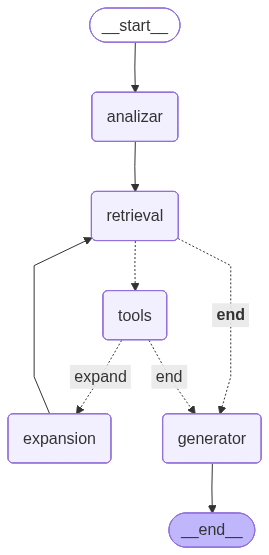

In [8]:
# Configuración del Grafo

workflow = StateGraph(AgentState)

# Nodos
workflow.add_node("analizar", analysis_node)
workflow.add_node("retrieval", retrieval_node)
workflow.add_node("tools", ToolNode([retrieve_docs]))
workflow.add_node("expansion", expansion_node)
workflow.add_node("generator", generator_node)

# --- FLUJO ---
workflow.set_entry_point("analizar")
workflow.add_edge("analizar", "retrieval")

# 1. El Agente decide: ¿Uso la tool o respondo?
workflow.add_conditional_edges(
    "retrieval",
    tools_condition,
    {
        "tools": "tools",       # Si hay tool_calls, va al nodo 'tools'
        "__end__": "generator"  # Si terminó, va al nodo 'generator'
    }
)

# 2. Después de la Tool: ¿La información es buena? (Tu Gatekeeper)
workflow.add_conditional_edges(
    "tools",
    grade_retrieval, # Aquí usas tu lógica de score < 1.5
    {
        "expand": "expansion",
        "end": "generator",
        "fail": "generator"
    }
)

# El bucle: La expansión vuelve a preparar la búsqueda
workflow.add_edge("expansion", "retrieval")

workflow.add_edge("generator", END)

app = workflow.compile()
app

In [10]:
q = "Whats the last article about?"
q = "List me the last post related to Inteligencia Artificial"
# q="List me all post related to RAG"
# q="list articles or testing of 2024"
# # q = "what is amazon's revenue in 2024?"
q = "whats a vector store?"
# q = "Whats is the last article about?"
# q = "Last article about?"
# q = "Whats Retreival Augmnted Generation?"
# q = "whats the last article about?"
# q = "Whats a Rag?"

result = app.invoke({'messages': [HumanMessage(q)]})

result['messages'][-1].pretty_print()

--- [ANALYSIS] Analizando query: whats a vector store? ---
[ANALYSIS] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': None, 'top_k': 10}

[NODE] Query: whats a vector store?
[NODE] Strategic Route: RetrievalRoute.CONVENCIONAL
[NODE] Params from Analyzer: {'sort_by': None, 'top_k': 10}

[TOOL] retrieve_docs called for query: vector store
--- [TOOL] Ejecutando búsqueda para ruta: RetrievalRoute.CONVENCIONAL ---
[TOOL] Usando parámetros del Analyzer -> Route: RetrievalRoute.CONVENCIONAL, Sort: None, TopK: 10
[TOOL] Filters: {}
[MODE] Convencional - Ranking Keywords: ['Vector Search', 'Embeddings', 'Semantic Search', 'MCP', 'Model Context Protocol']
   [BM25 Rank 1] Doc 22: score=7.0266
   [BM25 Rank 2] Doc 18: score=6.8403
   [BM25 Rank 3] Doc 10: score=5.7500
   [BM25 Rank 4] Doc 21: score=3.2672
   [BM25 Rank 5] Doc 13: score=3.2412
   [BM25 Rank 6] Doc 2: score=3.2208
   [BM25 Rank 7] Doc 6: score=3.2179
   [BM25 Rank 8] Doc 15: score=3.2160
   [BM25 Rank 9] Doc 39: score=3.21

In [8]:
# q = "Whats a RAG?"
q = "whats the last article about?"

result = app.invoke({'messages': [HumanMessage(q)]})

--- [ANALYSIS] Analizando query: whats the last article about? ---
[ANALYSIS] Route: RetrievalRoute.FAST | Params: {'sort_by': 'date_ts', 'top_k': 1}

[NODE] Query: whats the last article about?
[NODE] Strategic Route: RetrievalRoute.FAST
[NODE] Params from Analyzer: {'sort_by': 'date_ts', 'top_k': 1}

[TOOL] retrieve_docs called for query: what is the last article about
--- [TOOL] Ejecutando búsqueda para ruta: RetrievalRoute.FAST ---
[TOOL] Usando parámetros del Analyzer -> Route: RetrievalRoute.FAST, Sort: date_ts, TopK: 1
[TOOL] Filters: {}
[MODE] Fast Retrieval - Skipping semantic
[TOOL] Aplicando post-proceso: Sort by date_ts, Limit 1

--- [NODE] Generando respuesta final ---
